# Import Libraries

In [14]:
import os
import numpy as np
import pandas as pd
from pathlib import Path


import torch
import torchvision
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import torch.nn as nn
import torch.optim as optim

import time

Importing important required libraries

In [2]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Fixes the randoom seed values for PyTorch and NumPy for consistent results.

# Device Setup

In [3]:
# Device configuration - prioritize MPS (Metal Performance Shaders) for Mac
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


Notebook is using GPU

# Dataset path

In [33]:
# Base path
BASE_PATH = "/Users/shreyash/Documents/Sem3DL/AT2DL"
DATA_PATH = os.path.join(BASE_PATH, "food-101")

# Verify dataset path
print("Dataset path exists:", os.path.exists(DATA_PATH))
print("")
# Check dataset structure
print("Top-level folders:")
print(os.listdir(DATA_PATH))

Dataset path exists: True

Top-level folders:
['.DS_Store', 'images', 'meta', 'license_agreement.txt', 'README.txt']


Dataset path validation check.

# Dataset Preprocessing:

In [5]:
class Food101Dataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        self.root_dir = root_dir
        self.transform = transform

        meta_path = os.path.join(root_dir, "meta")
        file_path = os.path.join(meta_path, f"{split}.txt")

        with open(file_path, "r") as f:
            self.image_paths = [line.strip() for line in f.readlines()]

        with open(os.path.join(meta_path, "classes.txt"), "r") as f:
            self.classes = [line.strip() for line in f.readlines()]

        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_rel_path = self.image_paths[idx]
        label_name = img_rel_path.split('/')[0]

        img_path = os.path.join(self.root_dir, "images", img_rel_path + ".jpg")
        image = Image.open(img_path).convert("RGB")

        label = self.class_to_idx[label_name]

        if self.transform:
            image = self.transform(image)

        return image, label

Custom PyTorch dataset for Food101

# Normalize and Transforms

In [6]:
# ImageNet normalization values
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# Training transforms (with augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

# Test transforms (no augmentation)
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

Preprocessesing step for training and test images transformed: resized and normalized (training are lighly augmented with flip and rotation)

# Load Dataset

In [7]:
train_dir = os.path.join(DATA_PATH, "train")
test_dir = os.path.join(DATA_PATH, "test")

train_dataset = Food101Dataset(DATA_PATH, split='train', transform=train_transforms)
test_dataset = Food101Dataset(DATA_PATH, split='test', transform=test_transforms)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))
print("Number of classes:", len(train_dataset.classes))

Training samples: 75750
Test samples: 25250
Number of classes: 101


# Batch size and DataLoaders

In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
# Sanity check
images, labels = next(iter(train_loader))
print("Batch shape:", images.shape)
print("Labels shape:", labels.shape)

Batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])


Each batch has 32 RGB images, resized to 224x224.

# Model Function

### Transfer Learning Setup

Pre-trained convolutional neural networks trained on ImageNet are used as feature extractors.

All backbone layers are frozen to retain learned visual features such as edges, textures, and shapes. Only the final classification head is replaced and trained on the Food101 dataset.

Each new head consists of three fully connected layers, allowing the model to adapt to 101 food categories without retraining the entire network.

In [11]:
def get_model(model_name, num_classes=101):
    if model_name == "resnet":
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = model.fc.in_features

        # Freeze backbone
        for param in model.parameters():
            param.requires_grad = False

        # Replace head
        model.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    elif model_name == "googlenet":
        model = models.googlenet(weights=models.GoogLeNet_Weights.DEFAULT)
        in_features = model.fc.in_features

        for param in model.parameters():
            param.requires_grad = False

        model.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    elif model_name == "mobilenet":
        model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
        in_features = model.classifier[0].in_features

        for param in model.parameters():
            param.requires_grad = False

        model.classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    else:
        raise ValueError("Invalid model name")

    return model.to(device)

Function to call 3 pre-trained models: ResNet, GoogLeNet, or MobileNetV3.

Freezed the pretrained backbone layers and replaced the original classifier with a new three-layer fully connected head.

# Initializing Models

In [12]:
resnet_model = get_model("resnet")
googlenet_model = get_model("googlenet")
mobilenet_model = get_model("mobilenet")

print("Models initialized successfully")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/shreyash/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /Users/shreyash/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100.0%


Models initialized successfully


### Model Architectures

Three different pre-trained architectures are used to compare performance under the same transfer learning setup.

- ResNet uses skip connections that allow deeper networks to learn effectively.
- GoogLeNet uses Inception modules to process multiple feature scales in parallel.
- MobileNetV3 is designed for efficiency using lightweight operations and optimized blocks.

These models differ in complexity, parameter size, and learning behavior, making them suitable for comparison.

# Training Models:

In [ ]:
def train_model(model, train_loader, test_loader, epochs=10):
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

    model.to(device)

    for epoch in range(epochs):
        start_time = time.time()

        # Training
        model.train()
        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            # For GoogLeNet
            if isinstance(outputs, tuple):
                outputs = outputs[0]


            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            #train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / total
        train_acc = 100 * correct / total

        # Validation
        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                # For GoogLeNet
                if isinstance(outputs, tuple):
                    outputs = outputs[0]
                
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_loss = val_loss / total
        val_acc = 100 * correct / total

        end_time = time.time()

        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
              f"Time: {end_time - start_time:.2f}s")

    return model

Training is performed using cross-entropy loss, which is suitable for multi-class classification problems.

The Adam optimizer is used to update only the parameters of the new classification head. The pretrained backbone remains frozen throughout training.

The models are trained for 10 epochs with a batch size of 32. Performance is evaluated using accuracy on the test set after each epoch.

## 1. ResNet training:

In [20]:
trained_resnet = train_model(resnet_model, train_loader, test_loader, epochs=10)

Epoch [1/10] | Train Loss: 2.7964 | Train Acc: 31.72% | Val Loss: 2.1972 | Val Acc: 44.60% | Time: 493.66s
Epoch [2/10] | Train Loss: 2.7559 | Train Acc: 32.65% | Val Loss: 2.2122 | Val Acc: 43.61% | Time: 521.11s
Epoch [3/10] | Train Loss: 2.7312 | Train Acc: 33.25% | Val Loss: 2.1896 | Val Acc: 45.36% | Time: 539.73s
Epoch [4/10] | Train Loss: 2.7140 | Train Acc: 33.65% | Val Loss: 2.1491 | Val Acc: 45.53% | Time: 535.52s
Epoch [5/10] | Train Loss: 2.7021 | Train Acc: 33.96% | Val Loss: 2.2021 | Val Acc: 45.33% | Time: 601.68s
Epoch [6/10] | Train Loss: 2.6885 | Train Acc: 34.40% | Val Loss: 2.1708 | Val Acc: 45.80% | Time: 575.05s
Epoch [7/10] | Train Loss: 2.6789 | Train Acc: 34.61% | Val Loss: 2.1747 | Val Acc: 46.09% | Time: 592.55s
Epoch [8/10] | Train Loss: 2.6763 | Train Acc: 34.78% | Val Loss: 2.1457 | Val Acc: 45.93% | Time: 579.55s
Epoch [9/10] | Train Loss: 2.6690 | Train Acc: 34.94% | Val Loss: 2.1410 | Val Acc: 46.34% | Time: 638.18s
Epoch [10/10] | Train Loss: 2.6646 | 

ResNet shows steady learning, with validation accuracy improving consistently across 10 epochs.

The skip connections helps retain useful feature representations, enabling effective adaptation even when the backbone remains frozen.

Performance stabilizes around 45–46% validation accuracy, suggesting that most gains are achieved early and further improvement is limited when only the classification head is trained.

In [21]:
def compute_accuracy(model, data_loader):
    model.eval()
    
    num_correct = 0
    num_samples = 0

    with torch.no_grad():
        for batch_images, batch_labels in data_loader:
            batch_images = batch_images.to(device)
            batch_labels = batch_labels.to(device)

            predictions = model(batch_images)
            predicted_classes = predictions.argmax(dim=1)

            num_samples += batch_labels.size(0)
            num_correct += (predicted_classes == batch_labels).sum().item()

    accuracy = (num_correct / num_samples) * 100
    print(f"Model Accuracy: {accuracy:.2f}%")
    
    return accuracy

## Evaluating ResNet

In [22]:
fin_res_acc = compute_accuracy(trained_resnet, test_loader)
print("Final ResNet Accuracy:", fin_res_acc)

results = {}
results["ResNet"] = fin_res_acc

Model Accuracy: 45.29%
Final ResNet Accuracy: 45.28712871287129


Model Accuracy: 45.29% shows the final ResNet test performance.
This means the frozen ResNet backbone plus custom head can classify Food101 at a moderate level.

## 2. Training GoogLeNet:

In [25]:
trained_googlenet = train_model(googlenet_model, train_loader, test_loader, epochs=10)

Epoch [1/10] | Train Loss: 3.6214 | Train Acc: 15.17% | Val Loss: 2.7452 | Val Acc: 31.46% | Time: 707.93s
Epoch [2/10] | Train Loss: 3.2015 | Train Acc: 23.07% | Val Loss: 2.5857 | Val Acc: 35.24% | Time: 673.86s
Epoch [3/10] | Train Loss: 3.1222 | Train Acc: 24.59% | Val Loss: 2.5426 | Val Acc: 36.65% | Time: 576.26s
Epoch [4/10] | Train Loss: 3.0849 | Train Acc: 25.59% | Val Loss: 2.4713 | Val Acc: 38.70% | Time: 543.53s
Epoch [5/10] | Train Loss: 3.0548 | Train Acc: 26.40% | Val Loss: 2.4797 | Val Acc: 39.39% | Time: 582.45s
Epoch [6/10] | Train Loss: 3.0570 | Train Acc: 26.39% | Val Loss: 2.4692 | Val Acc: 39.12% | Time: 601.85s
Epoch [7/10] | Train Loss: 3.0368 | Train Acc: 26.97% | Val Loss: 2.4407 | Val Acc: 40.43% | Time: 589.69s
Epoch [8/10] | Train Loss: 3.0385 | Train Acc: 27.13% | Val Loss: 2.4401 | Val Acc: 40.99% | Time: 461.58s
Epoch [9/10] | Train Loss: 3.0265 | Train Acc: 27.36% | Val Loss: 2.4206 | Val Acc: 40.63% | Time: 429.22s
Epoch [10/10] | Train Loss: 3.0203 | 

GoogLeNet learns more slowly compared to ResNet and reaches a lower final accuracy.

The Inception structure processes multiple feature scales, but this complexity does not translate well when the backbone is frozen.

This suggests that GoogLeNet may require more fine-tuning to perform better on this dataset.

## Evaluating GoogLeNet

In [26]:
googlenet_acc = compute_accuracy(trained_googlenet, test_loader)
print("Final GoogLeNet Accuracy:", googlenet_acc)

results["GoogLeNet"] = googlenet_acc

Model Accuracy: 40.07%
Final GoogLeNet Accuracy: 40.071287128712875


Model Accuracy: 40.07% shows GoogLeNet had the lowest final score among the models tested so far.
It still learned the task, but its performance was weaker than ResNet.

## 3. Training MobileNetV3

In [27]:
trained_mobilenet = train_model(mobilenet_model, train_loader, test_loader, epochs=10)

Epoch [1/10] | Train Loss: 3.2897 | Train Acc: 21.63% | Val Loss: 2.3921 | Val Acc: 39.76% | Time: 223.12s
Epoch [2/10] | Train Loss: 2.8112 | Train Acc: 31.25% | Val Loss: 2.1905 | Val Acc: 44.44% | Time: 225.04s
Epoch [3/10] | Train Loss: 2.6828 | Train Acc: 34.37% | Val Loss: 2.1127 | Val Acc: 45.45% | Time: 235.79s
Epoch [4/10] | Train Loss: 2.6166 | Train Acc: 35.87% | Val Loss: 2.0354 | Val Acc: 48.43% | Time: 225.77s
Epoch [5/10] | Train Loss: 2.5682 | Train Acc: 36.75% | Val Loss: 2.0001 | Val Acc: 48.60% | Time: 238.84s
Epoch [6/10] | Train Loss: 2.5288 | Train Acc: 37.88% | Val Loss: 1.9777 | Val Acc: 49.55% | Time: 224.81s
Epoch [7/10] | Train Loss: 2.5028 | Train Acc: 38.60% | Val Loss: 1.9650 | Val Acc: 50.45% | Time: 227.39s
Epoch [8/10] | Train Loss: 2.4831 | Train Acc: 39.12% | Val Loss: 1.9536 | Val Acc: 50.07% | Time: 244.80s
Epoch [9/10] | Train Loss: 2.4618 | Train Acc: 39.52% | Val Loss: 1.9539 | Val Acc: 50.49% | Time: 277.37s
Epoch [10/10] | Train Loss: 2.4441 | 

MobileNetV3 achieves the highest accuracy among all models.

Its lightweight design allows faster training and better adaptation to the new dataset. The architecture appears to transfer features more effectively under the frozen backbone setting.

The model shows consistent improvement across epochs with better generalization.

## Evaluating MobileNetV3

In [ ]:
mobilenet_acc = compute_accuracy(trained_mobilenet, test_loader)
print("Final MobileNet Accuracy:", mobilenet_acc)

results["MobileNetV3"] = mobilenet_acc


Model Accuracy: 51.16%
Final MobileNet Accuracy: 51.16435643564357


Model Accuracy: 51.16% shows MobileNetV3 is the best-performing model in Part A.
This means it gave the strongest classification performance with the frozen pretrained backbone.

# Test Accuracy Comparison

In [ ]:
print("Final Model Comparison on Test Set:")
for model_name, acc in results.items():
    print(f"{model_name}: {acc:.2f}%")

Final Model Comparison on Test Set:
ResNet: 45.29%
GoogLeNet: 40.07%
MobileNetV3: 51.16%


In [32]:
results_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Test Accuracy (%)": list(results.values())
})

results_df = results_df.sort_values(by="Test Accuracy (%)", ascending=False).reset_index(drop=True)
print(results_df)

         Model  Test Accuracy (%)
0  MobileNetV3          51.164356
1       ResNet          45.287129
2    GoogLeNet          40.071287


The final ranking shows ResNet at 45.29%, GoogLeNet at 40.07%, and MobileNetV3 at 51.16%.

MobileNetV3 outperforms both ResNet and GoogLeNet in this experiment.

ResNet performs reasonably well due to its skip connections, which help maintain useful feature representations. GoogLeNet shows lower performance, possibly due to its more complex structure and reduced adaptability when frozen.

MobileNetV3 provides the best balance between simplicity and performance. Its efficient design allows it to adapt more effectively to the Food101 dataset.

# Model Comparison and Performance Analysis

In this experiment, three pre-trained convolutional neural network architectures : ResNet, GoogLeNet, and MobileNetV3 were evaluated on the Food101 dataset using transfer learning. For all models, the pre-trained backbone was frozen, and a custom classification head consisting of three fully connected layers were trained.

# Performance Summary

| Model         | Test Accuracy (%) |
|--------------|------------------|
| MobileNetV3  | 51.16            |
| ResNet       | 45.29            |
| GoogLeNet    | 40.07            |

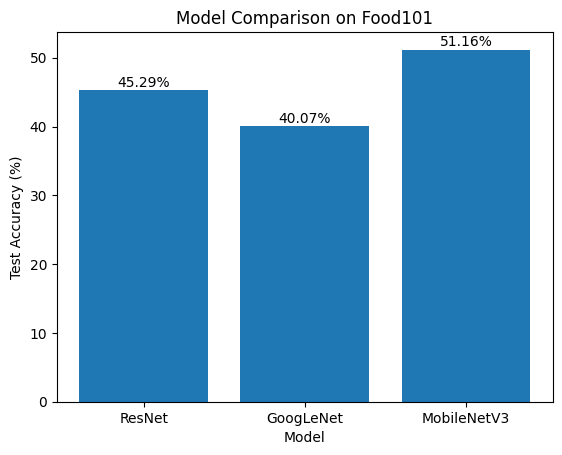

In [ ]:
import matplotlib.pyplot as plt

model_names = list(results.keys())
accuracies = list(results.values())

plt.figure()
plt.bar(model_names, accuracies)

plt.title("Model Comparison on Food101")
plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center')

plt.show()

# Observations

MobileNetV3 achieved the highest accuracy among the three models, followed by ResNet, while GoogLeNet showed the lowest performance. This indicates that MobileNetV3 was the most effective architecture for transfer learning under the constraint of freezing the pre-trained layers.

# Architectural Insights

ResNet utilizes residual (skip) connections, which help mitigate the vanishing gradient problem and allow deeper networks to learn effectively. This contributes to its relatively strong performance.

GoogLeNet is based on Inception modules, which perform multiple convolutions at different scales in parallel. While this design is computationally efficient, it can be harder to optimize when the network is frozen, leading to lower performance in transfer learning.

MobileNetV3 is designed as a lightweight and efficient architecture using depthwise separable convolutions and optimized building blocks. Despite having fewer parameters, it adapts well to new tasks and demonstrates strong feature generalization, which explains its superior performance in this experiment.

# Conclusion

Among the three models, MobileNetV3 provided the best trade-off between efficiency and accuracy, making it the most suitable candidate for further fine-tuning in Part B of this assignment.